In [ ]:
#SILVA
#CPE 3B
#TRANSFER FUNCTION

In [17]:
!pip install sympy


   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ------------- -------------------------- 2.1/6.3 MB 14.4 MB/s eta 0:00:01
   ---------------------------------------- 6.3/6.3 MB 26.7 MB/s  0:00:00
   ---------------------------------------- 0.0/536.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/536.2 kB ? eta -:--:--
   ---------------------------------------- 536.2/536.2 kB 2.9 MB/s  0:00:00

   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import control as ctrl

In [32]:

# 1. Define Symbols
s = sp.symbols('s')
X, Y = sp.symbols('X Y')

# 2. Equation: 2s^2Y + sY = sX + X
A = 2*s**2 * Y + s * Y
B = s * X + X

In [33]:
# 3. Solve for Transfer Function Y/X
tf_expr = sp.solve(sp.Eq(A, B), Y)[0] / X
tf_simplified = sp.simplify(tf_expr)

print("Calculated Transfer Function G(s):", tf_simplified)

Calculated Transfer Function G(s): (s + 1)/(s*(2*s + 1))


In [34]:
# 4. Convert to Control Library
num_coeffs = [float(c) for c in sp.Poly(sp.numer(tf_simplified), s).all_coeffs()]
den_coeffs = [float(c) for c in sp.Poly(sp.denom(tf_simplified), s).all_coeffs()]

sys = ctrl.tf(num_coeffs, den_coeffs)
print(sys)

<TransferFunction>: sys[3]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    s + 1
  ---------
  2 s^2 + s


In [35]:
# 5. Poles and Zeros
print(f"Transfer Function: G(s) = (s + 1) / (2s^2 + s)")

p = ctrl.poles(sys)
z = ctrl.zeros(sys)

print("Poles:", p)
print("Zeros:", z)

Transfer Function: G(s) = (s + 1) / (2s^2 + s)
Poles: [-0.5+0.j  0. +0.j]
Zeros: [-1.+0.j]


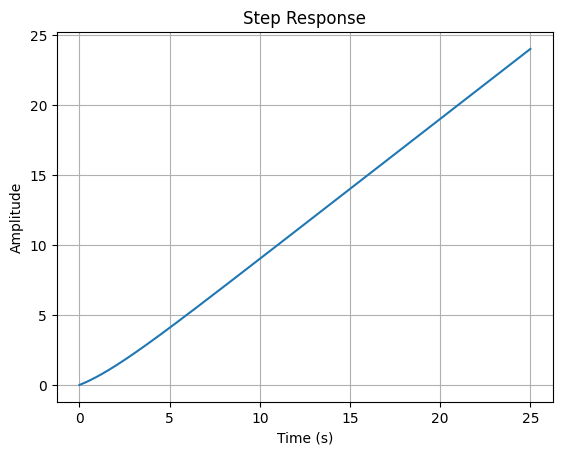

In [36]:
# 6. Step Response (FIX: define time range for smoother graph)
t = np.linspace(0, 25, 1000)
t, y = ctrl.step_response(sys, t)

plt.figure()
plt.plot(t, y)
plt.title('Step Response')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

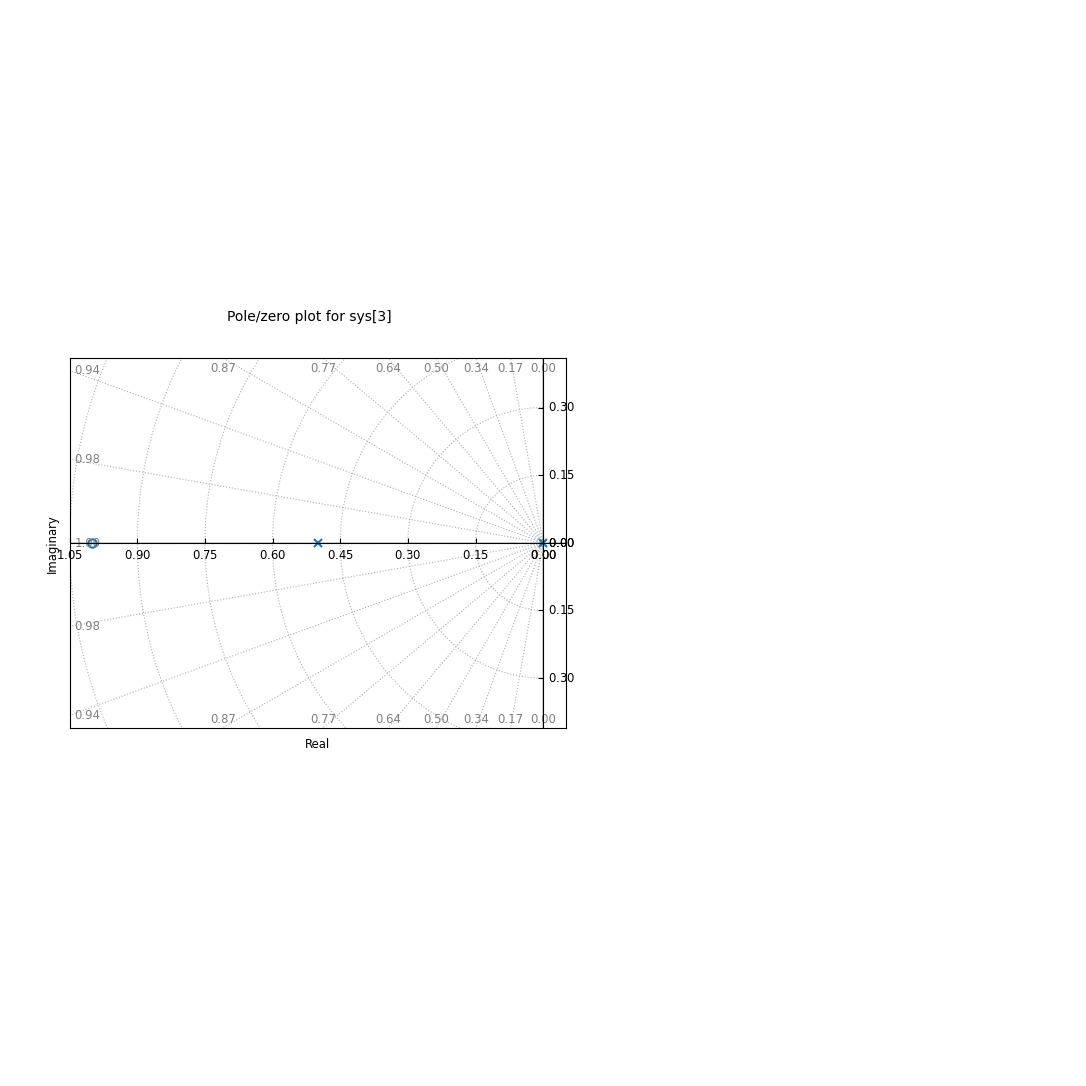

In [37]:
# 7. Pole-Zero Map (separate figure for clarity)
plt.figure()
ctrl.pzmap(sys, grid=True)

plt.show()